Verify the modified Runge-Kutta method can actually generate the MGdata with reasonable error

Mackey-Glass Time Series
$$
\frac{dP(t)}{dt} = \frac{\beta\theta^nP(t-\tau)}{\theta^n+P(t-\tau)^n}-\gamma P(t)
$$

In [6]:
import numpy as np

define two methods

In [14]:
# verify the RK method to generate MG data

## RK method where treat x(t-\tau) unchanged when t change

def MG_generate(gamma=0.1,beta=0.2,tau=23,theta=0.2,n=10,x0=0.2,N=1000000,delta=0.01,interval=1):
  def MG_eq (x,x_pre):
    return x_pre * beta * (theta**n)/(theta**n+x_pre**n)-gamma*x

  def MG_rk4(x,x_pre):
    k1 = MG_eq(x,x_pre)
    k2 = MG_eq(x+delta*k1/2,x_pre)
    k3 = MG_eq(x+delta*k2/2,x_pre)
    k4 = MG_eq(x+delta*k3,x_pre)
    return x+delta*(k1+2*k2+2*k3+k4)/6

  past_len = int(np.floor(tau/delta))
  x_past = np.zeros(past_len+N+1)
  x = x0
  X = np.zeros(N+1)
  T = np.zeros(N+1)
  time = 0

  for i in range(N+1):
    X[i] = x
    x_pre = x_past[i]
    x_delta = MG_rk4(x=x,x_pre=x_pre)
    x_past[i+past_len] = x_delta
    T[i] = time
    time += delta
    x = x_delta

  return T,X

In [15]:
## Yular method

def MG_generate_YL(gamma=0.1,beta=0.2,tau=23,theta=0.2,n=10,x0=0.2,N=1000000,delta=0.01,interval=1):
  past_len = int(np.floor(tau/delta))
  x_past = np.zeros(past_len+N+1)
  x = x0
  X = np.zeros(N+1)
  T = np.zeros(N+1)
  time = 0
  for i in range(N+1):
    X[i] = x
    x_pre = x_past[i]
    x_delta = x+delta*(beta*theta**n*x_pre/(theta**n+x_pre**n)-gamma*x)
    x_past[i+past_len] = x_delta
    T[i] = time
    time += delta
    x = x_delta

  return T,X

compare results

In [ ]:
import matplotlib.pyplot as plt

In [4]:
T_RK, X_RK = MG_generate()
T_YL, X_YL = MG_generate_YL()

RK+method of steps

In [16]:
def MG_generate_interp(gamma=0.1,beta=0.2,tau=23,theta=0.2,n=10,x0=0.2,N=1000000,delta=0.01,interval=1):
  def MG_eq (x,x_pre):
    return x_pre * beta * (theta**n)/(theta**n+x_pre**n)-gamma*x

  def MG_rk4(x,x_pre,x_pre_f):
    interplot = (x_pre+x_pre_f)/2
    k1 = MG_eq(x,x_pre)
    k2 = MG_eq(x+delta*k1/2,interplot)
    k3 = MG_eq(x+delta*k2/2,interplot)
    k4 = MG_eq(x+delta*k3,x_pre_f)
    return x+delta*(k1+2*k2+2*k3+k4)/6

  past_len = int(np.floor(tau/delta))
  x_past = np.zeros(past_len+N+1)
  x = x0
  X = np.zeros(N+1)
  T = np.zeros(N+1)
  time = 0

  for i in range(N+1):
    X[i] = x
    x_pre = x_past[i]
    x_pre_f = x_past[i+1]
    x_delta = MG_rk4(x=x,x_pre=x_pre,x_pre_f = x_pre_f)
    x_past[i+past_len] = x_delta
    T[i] = time
    time += delta
    x = x_delta

  return T,X

compare

In [17]:
T_RK_interp, X_RK_interp = MG_generate_interp(tau = 50)
T_RK, X_RK = MG_generate(tau=50)
T_YL, X_YL = MG_generate_YL(tau=50)

In [18]:
diff = abs(np.array(X_YL)-np.array(X_RK))

In [19]:
sum(diff)/len(diff)

np.float64(0.06535721722839283)

In [20]:
diff = abs(np.array(X_YL)-np.array(X_RK_interp))

In [21]:
sum(diff)/len(diff)

np.float64(0.06402812791196448)

In [12]:
diff = abs(np.array(X_RK)-np.array(X_RK_interp))

In [13]:
sum(diff)/len(diff)

np.float64(0.060407076764410414)

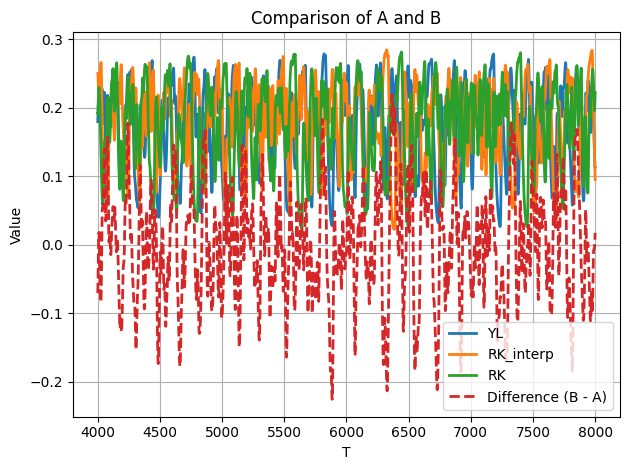

In [198]:
diff = np.array(X_YL)-np.array(X_RK_interp)

plt.plot(T_YL[::100][4000:8001], X_YL[::100][4000:8001], label='YL', linewidth=2)
plt.plot(T_RK_interp[::100][4000:8001], X_RK_interp[::100][4000:8001], label='RK_interp', linewidth=2)
plt.plot(T_RK[::100][4000:8001], X_RK[::100][4000:8001], label='RK', linewidth=2)
plt.plot(T_YL[::100][4000:8001], diff[::100][4000:8001], label='Difference (B - A)', linestyle='--',linewidth=2)

plt.xlabel('T')
plt.ylabel('Value')
plt.title('Comparison of A and B')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Test how to compute l.e.

In [61]:
!pip install nolds

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 4.4 MB/s eta 0:00:00


In [62]:
import nolds

In [234]:
data = X_RK[::100][5000:10000]
fft_vals = np.fft.rfft(data)
psd = np.abs(fft_vals)**2
freqs = np.fft.rfftfreq(len(data))

# Skip DC component at index 0
mean_freq = np.sum(freqs[1:] * psd[1:]) / np.sum(psd[1:])
mean_period = 1 / mean_freq
min_tsep = int(round(mean_period))
min_tsep

86

In [235]:
data = X_RK[::100][5000:10000]
lyap_est = nolds.lyap_r(data,emb_dim=10,min_tsep=86)
print(lyap_est)

0.012176519203466771


/usr/local/lib/python3.11/dist-packages/nolds/measures.py:282: RuntimeWarning: autocorrelation declined too slowly to find suitable lag, setting lag to 532
  warnings.warn(msg.format(lag), RuntimeWarning)


In [232]:
data = X_YL[::100][5000:10000]
fft_vals = np.fft.rfft(data)
psd = np.abs(fft_vals)**2
freqs = np.fft.rfftfreq(len(data))

# Skip DC component at index 0
mean_freq = np.sum(freqs[1:] * psd[1:]) / np.sum(psd[1:])
mean_period = 1 / mean_freq
min_tsep = int(round(mean_period))
min_tsep

85

In [233]:
data = X_YL[::100][5000:10000]
lyap_est = nolds.lyap_r(data,emb_dim=10,min_tsep=85)
print(lyap_est)

0.020209342662613875


/usr/local/lib/python3.11/dist-packages/nolds/measures.py:282: RuntimeWarning: autocorrelation declined too slowly to find suitable lag, setting lag to 533
  warnings.warn(msg.format(lag), RuntimeWarning)


In [230]:
data = X_RK_interp[::100][5000:10000]
fft_vals = np.fft.rfft(data)
psd = np.abs(fft_vals)**2
freqs = np.fft.rfftfreq(len(data))

# Skip DC component at index 0
mean_freq = np.sum(freqs[1:] * psd[1:]) / np.sum(psd[1:])
mean_period = 1 / mean_freq
min_tsep = int(round(mean_period))
min_tsep

82

In [231]:
data = X_RK_interp[::100][5000:10000]
lyap_est = nolds.lyap_r(data,emb_dim=10,min_tsep=82)
print(lyap_est)

0.02322469620143682


/usr/local/lib/python3.11/dist-packages/nolds/measures.py:282: RuntimeWarning: autocorrelation declined too slowly to find suitable lag, setting lag to 533
  warnings.warn(msg.format(lag), RuntimeWarning)


# Experiments

Mackey-Glass Time Series
$$
\frac{dP(t)}{dt} = \frac{\beta\theta^nP(t-\tau)}{\theta^n+P(t-\tau)^n}-\gamma P(t)
$$

We choose the interpolation version of RK method.
For parameters, we choose $\theta=1,n=10,\beta=0.2,\gamma = 0.1,x(t)=0.1 \ \forall t <0$. And the $\tau=60,120,200,x_0 = 0.2,0.4,1,3,5,7,8$. For fine-tune fraction, we will choose 5%, 30%, 75%

Firstly, method to generate data

**RK4 Interpolation Method**:
            
$$
\begin{aligned}
    \tilde{x}_{n-\tau} &= \frac{x_{n-\tau} + x_{n-\tau+1}}{2} \\
    k_1 &= f(x_n, x_{n-\tau}) \\
    k_2 &= f\left(x_n + \frac{\Delta t}{2}k_1, \tilde{x}_{n-\tau}\right) \\
    k_3 &= f\left(x_n + \frac{\Delta t}{2}k_2, \tilde{x}_{n-\tau}\right) \\
    k_4 &= f\left(x_n + \Delta t\cdot k_3, x_{n-\tau+1}\right) \\
    x_{n+1} &= x_n + \frac{\Delta t}{6}(k_1 + 2k_2 + 2k_3 + k_4)
\end{aligned}
$$

In [1]:
import numpy as np
def MG_generate_interp(gamma=0.1,beta=0.2,tau=60,theta=1,n=10,x0=0.2,N=1000000,delta=0.01,interval=1):
  def MG_eq (x,x_pre):
    return x_pre * beta * (theta**n)/(theta**n+x_pre**n)-gamma*x

  def MG_rk4(x,x_pre,x_pre_f):
    interplot = (x_pre+x_pre_f)/2
    k1 = MG_eq(x,x_pre)
    k2 = MG_eq(x+delta*k1/2,interplot)
    k3 = MG_eq(x+delta*k2/2,interplot)
    k4 = MG_eq(x+delta*k3,x_pre_f)
    return x+delta*(k1+2*k2+2*k3+k4)/6

  past_len = int(np.floor(tau/delta))
  x_past = np.zeros(past_len+N+1)+0.1
  x = x0
  X = np.zeros(N+1)
  T = np.zeros(N+1)
  time = 0

  for i in range(N+1):
    X[i] = x
    x_pre = x_past[i]
    x_pre_f = x_past[i+1]
    x_delta = MG_rk4(x=x,x_pre=x_pre,x_pre_f = x_pre_f)
    x_past[i+past_len] = x_delta
    T[i] = time
    time += delta
    x = x_delta

  return T,X

generate and save the data

In [2]:
x_0s = [0.2,0.4,1,3,5,7,8]
taus = [60,120,200]

In [6]:
import pandas as pd
import os

save_dir = "/content/MGdatasets"
os.makedirs(save_dir, exist_ok=True)

for x_0 in x_0s:
    for tau in taus:

        dataset_name = f"MG_x0_{x_0}_tau_{tau}"
        T, X = MG_generate_interp(x0=x_0, tau=tau)

        df = pd.DataFrame({"time": T, "value": X})
        df.to_csv(os.path.join(save_dir, f"{dataset_name}.csv"), index=False)

load, transform, train and save

In [ ]:
!pip install "granite-tsfm[notebooks] @ git+https://github.com/ibm-granite/granite-tsfm.git@v0.2.22"
!pip install numpy==1.25.2
!pip install --upgrade --force-reinstall pandas

In [1]:
import math
import os
import tempfile
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from transformers import EarlyStoppingCallback, Trainer, TrainingArguments, set_seed
from transformers.integrations import INTEGRATION_TO_CALLBACK

from tsfm_public import TimeSeriesPreprocessor, TrackingCallback, count_parameters, get_datasets
from tsfm_public.toolkit.get_model import get_model
from tsfm_public.toolkit.lr_finder import optimal_lr_finder
from tsfm_public.toolkit.visualization import plot_predictions

In [2]:
timestamp_column_MG = "time"
id_columns_MG = []  # mention the ids that uniquely identify a time-series.

target_columns_MG = ["P"]
split_config_MG = {
    "train": [0, 6000],
    "valid": [6000, 9000],
    "test": [
        9000,
        10001,
    ],
}
column_specifiers_MG = {
    "timestamp_column": timestamp_column_MG,
    "id_columns": id_columns_MG,
    "target_columns": target_columns_MG,
    "control_columns": [],
}

In [3]:
SEED = 42
set_seed(SEED)

# TTM Model path. The default model path is Granite-R2. Below, you can choose other TTM releases.
TTM_MODEL_PATH = "ibm-granite/granite-timeseries-ttm-r2"
# TTM_MODEL_PATH = "ibm-granite/granite-timeseries-ttm-r1"
# TTM_MODEL_PATH = "ibm-research/ttm-research-r2"

# Context length, Or Length of the history.
# Currently supported values are: 512/1024/1536 for Granite-TTM-R2 and Research-Use-TTM-R2, and 512/1024 for Granite-TTM-R1
CONTEXT_LENGTH = 512

# Granite-TTM-R2 supports forecast length upto 720 and Granite-TTM-R1 supports forecast length upto 96
PREDICTION_LENGTH = 96

OUT_DIR = "/content/drive/MyDrive/ColabBackup"

data_save_dir = "/content/drive/MyDrive/ColabBackup/MGdatasets"

In [5]:
def fewshot_finetune_eval_MG(
    dataset_name,
    batch_size,
    learning_rate=None,
    context_length=512,
    forecast_length=96,
    fewshot_percent=5,
    freeze_backbone=True,
    num_epochs=50,
    save_dir=OUT_DIR,
    loss="mse",
    quantile=0.5,
    location = "uniform",
):
    out_dir = os.path.join(save_dir,
                           f"{dataset_name}_{fewshot_percent}_{location}")

    os.makedirs(out_dir, exist_ok=True)

    print("-" * 20, f"Running few-shot {fewshot_percent}%", "-" * 20)

    # Data prep: Get dataset

    tsp = TimeSeriesPreprocessor(
        **column_specifiers_MG,
        context_length=context_length,
        prediction_length=forecast_length,
        scaling=True,
        encode_categorical=False,
        scaler_type="standard",
    )

    dset_train, dset_val, dset_test = get_datasets(
        tsp, MGdata, split_config_MG,
        fewshot_fraction=fewshot_percent / 100,
        fewshot_location=location
    )

    past_targets = []
    future_targets = []

    for i in range(len(dset_test)):
        past_targets.append(dset_test[i]['past_values'])
        future_targets.append(dset_test[i]['future_values'])

    dset_test_df = pd.DataFrame({
        'past_target': past_targets,
        'future_target': future_targets,
    })

    dset_test_df.to_csv(f"{out_dir}/dset_test.csv", index=False)


    finetune_forecast_model = get_model(
      TTM_MODEL_PATH,
      context_length=context_length,
      prediction_length=forecast_length,
      freq_prefix_tuning=False,
      freq=None,
      prefer_l1_loss=False,
      prefer_longer_context=True,
      # Can also provide TTM Config args
      loss=loss,
      quantile=quantile,
    )

    if freeze_backbone:
        print(
            "Number of params before freezing backbone",
            count_parameters(finetune_forecast_model),
        )

        # Freeze the backbone of the model
        for param in finetune_forecast_model.backbone.parameters():
            param.requires_grad = False

        # Count params
        print(
            "Number of params after freezing the backbone",
            count_parameters(finetune_forecast_model),
        )

    print(f"Using learning rate = {learning_rate}")
    finetune_forecast_args = TrainingArguments(
        output_dir=os.path.join(out_dir, "output"),
        overwrite_output_dir=True,
        learning_rate=learning_rate,
        num_train_epochs=num_epochs,
        do_eval=True,
        evaluation_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        dataloader_num_workers=8,
        report_to="none",
        save_strategy="epoch",
        logging_strategy="epoch",
        save_total_limit=1,
        logging_dir=os.path.join(out_dir, "logs"),  # Make sure to specify a logging directory
        load_best_model_at_end=True,  # Load the best model when training ends
        metric_for_best_model="eval_loss",  # Metric to monitor for early stopping
        greater_is_better=False,  # For loss
        seed=SEED,
    )

    # Create the early stopping callback
    early_stopping_callback = EarlyStoppingCallback(
        early_stopping_patience=10,  # Number of epochs with no improvement after which to stop
        early_stopping_threshold=1e-5,  # Minimum improvement required to consider as improvement
    )
    tracking_callback = TrackingCallback()

    # Optimizer and scheduler
    optimizer = AdamW(finetune_forecast_model.parameters(), lr=learning_rate)
    scheduler = OneCycleLR(
        optimizer,
        learning_rate,
        epochs=num_epochs,
        steps_per_epoch=math.ceil(len(dset_train) / (batch_size)),
    )

    finetune_forecast_trainer = Trainer(
        model=finetune_forecast_model,
        args=finetune_forecast_args,
        train_dataset=dset_train,
        eval_dataset=dset_val,
        callbacks=[early_stopping_callback, tracking_callback],
        optimizers=(optimizer, scheduler),
    )
    finetune_forecast_trainer.remove_callback(INTEGRATION_TO_CALLBACK["codecarbon"])

    # Fine tune
    finetune_forecast_trainer.train()

    # Evaluation
    print("+" * 20, f"Test MSE after few-shot {fewshot_percent}% fine-tuning", "+" * 20)

    finetune_forecast_trainer.model.loss = "mse"  # fixing metric to mse for evaluation

    fewshot_output = finetune_forecast_trainer.evaluate(dset_test)
    print(fewshot_output)
    print("+" * 60)

    # get predictions

    predictions_dict = finetune_forecast_trainer.predict(dset_test)

    predictions_np = predictions_dict.predictions[0]

    np.save(f"{out_dir}/predictions_original.npy", predictions_np)

    from copy import deepcopy

    dset_test_perturbed = deepcopy(dset_test)
    perturbation = 0.1

    for i in range(len(dset_test_perturbed)):
      sample = dset_test_perturbed[i]
      perturbed = sample['past_values'][:]
      perturbed[-1] += perturbation
      dset_test_perturbed[i]['past_values'] = perturbed

    predictions_dict_perturbed = finetune_forecast_trainer.predict(dset_test_perturbed)
    predictions_np_perturbed = predictions_dict_perturbed.predictions[0]
    np.save(f"{out_dir}/predictions_perturbed.npy", predictions_np_perturbed)


In [4]:
fracs = [5,30,75]
locations = ["last","uniform"]
x_0s_run = [0.2,1,5,8]

In [ ]:
for x_0 in x_0s_run:
  for tau in taus:
    if x_0 == 0.2 and tau == 60:
      continue
    for frac in fracs:
      for location in locations:
        dataset_name = f"MG_x0_{x_0}_tau_{tau}"
        df = pd.read_csv(f"{data_save_dir}/{dataset_name}.csv")
        T = df['time'].values
        X = df['value'].values
        MGdata = pd.DataFrame({
            'time': [round(x) for x in T[::100]],
            'P': X[::100],
        })
        fewshot_finetune_eval_MG(
            dataset_name=dataset_name,
            context_length=CONTEXT_LENGTH,
            forecast_length=PREDICTION_LENGTH,
            batch_size=64,
            fewshot_percent=frac,
            learning_rate=0.001,
            location = location,
        )



In [ ]:
for x_0 in x_0s_run:
  for tau in taus:
    if x_0 == 0.2 and tau == 60:
      continue
    for frac in fracs:
      for location in locations:
        dataset_name = f"MG_x0_{x_0}_tau_{tau}"
        df = pd.read_csv(f"{data_save_dir}/{dataset_name}.csv")
        T = df['time'].values
        X = df['value'].values
        MGdata = pd.DataFrame({
            'time': [round(x) for x in T[::100]],
            'P': X[::100],
        })
        fewshot_finetune_eval_MG(
            dataset_name=dataset_name,
            context_length=CONTEXT_LENGTH,
            forecast_length=PREDICTION_LENGTH,
            batch_size=64,
            fewshot_percent=frac,
            learning_rate=0.001,
            location = location,
        )

In [5]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
for x_0 in [5,8]:
  for tau in taus:
    for frac in fracs:
      for location in locations:
        dataset_name = f"MG_x0_{x_0}_tau_{tau}"
        df = pd.read_csv(f"{data_save_dir}/{dataset_name}.csv")
        T = df['time'].values
        X = df['value'].values
        MGdata = pd.DataFrame({
            'time': [round(x) for x in T[::100]],
            'P': X[::100],
        })
        fewshot_finetune_eval_MG(
            dataset_name=dataset_name,
            context_length=CONTEXT_LENGTH,
            forecast_length=PREDICTION_LENGTH,
            save_dir=OUT_DIR,
            batch_size=64,
            fewshot_percent=frac,
            learning_rate=0.001,
            location = location,
        )

In [2]:
import shutil
import os

def sync_content_to_drive(drive_folder='/content/drive/MyDrive/ColabBackup'):
    os.makedirs(drive_folder, exist_ok=True)

    for item in os.listdir('/content'):
        src_path = os.path.join('/content', item)
        dst_path = os.path.join(drive_folder, item)

        if os.path.isfile(src_path):
            shutil.copy2(src_path, dst_path)
            print(f'Copied file: {item}')

        elif os.path.isdir(src_path) and not src_path.startswith('/content/drive'):
            if os.path.exists(dst_path):
                shutil.rmtree(dst_path)
            shutil.copytree(src_path, dst_path)
            print(f'Copied folder: {item}')



In [ ]:
sync_content_to_drive()

In [7]:
def fewshot_finetune_eval_MG_temp(
    dataset_name,
    batch_size,
    learning_rate=None,
    context_length=512,
    forecast_length=96,
    fewshot_percent=5,
    freeze_backbone=True,
    num_epochs=50,
    save_dir=OUT_DIR,
    loss="mse",
    quantile=0.5,
    location = "uniform",
):
    out_dir = os.path.join(save_dir,
                           f"{dataset_name}_{fewshot_percent}_{location}")

    os.makedirs(out_dir, exist_ok=True)

    print("-" * 20, f"Running few-shot {fewshot_percent}%", "-" * 20)

    # Data prep: Get dataset

    tsp = TimeSeriesPreprocessor(
        **column_specifiers_MG,
        context_length=context_length,
        prediction_length=forecast_length,
        scaling=True,
        encode_categorical=False,
        scaler_type="standard",
    )

    dset_train, dset_val, dset_test = get_datasets(
        tsp, MGdata, split_config_MG,
        fewshot_fraction=fewshot_percent / 100,
        fewshot_location=location
    )

    past_targets = []
    future_targets = []

    for i in range(len(dset_test)):
        past_targets.append(dset_test[i]['past_values'])
        future_targets.append(dset_test[i]['future_values'])

    dset_test_df = pd.DataFrame({
        'past_target': past_targets,
        'future_target': future_targets,
    })

    dset_test_df.to_csv(f"{out_dir}/dset_test.csv", index=False)


    finetune_forecast_model = get_model(
      TTM_MODEL_PATH,
      context_length=context_length,
      prediction_length=forecast_length,
      freq_prefix_tuning=False,
      freq=None,
      prefer_l1_loss=False,
      prefer_longer_context=True,
      # Can also provide TTM Config args
      loss=loss,
      quantile=quantile,
    )

    if freeze_backbone:
        print(
            "Number of params before freezing backbone",
            count_parameters(finetune_forecast_model),
        )

        # Freeze the backbone of the model
        for param in finetune_forecast_model.backbone.parameters():
            param.requires_grad = False

        # Count params
        print(
            "Number of params after freezing the backbone",
            count_parameters(finetune_forecast_model),
        )

    print(f"Using learning rate = {learning_rate}")
    finetune_forecast_args = TrainingArguments(
        output_dir=os.path.join(out_dir, "output"),
        overwrite_output_dir=True,
        learning_rate=learning_rate,
        num_train_epochs=num_epochs,
        do_eval=True,
        evaluation_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        dataloader_num_workers=8,
        report_to="none",
        save_strategy="epoch",
        logging_strategy="epoch",
        save_total_limit=1,
        logging_dir=os.path.join(out_dir, "logs"),  # Make sure to specify a logging directory
        load_best_model_at_end=True,  # Load the best model when training ends
        metric_for_best_model="eval_loss",  # Metric to monitor for early stopping
        greater_is_better=False,  # For loss
        seed=SEED,
    )

    # Create the early stopping callback
    early_stopping_callback = EarlyStoppingCallback(
        early_stopping_patience=10,  # Number of epochs with no improvement after which to stop
        early_stopping_threshold=1e-5,  # Minimum improvement required to consider as improvement
    )
    tracking_callback = TrackingCallback()

    # Optimizer and scheduler
    optimizer = AdamW(finetune_forecast_model.parameters(), lr=learning_rate)
    scheduler = OneCycleLR(
        optimizer,
        learning_rate,
        epochs=num_epochs,
        steps_per_epoch=math.ceil(len(dset_train) / (batch_size)),
    )

    finetune_forecast_trainer = Trainer(
        model=finetune_forecast_model,
        args=finetune_forecast_args,
        train_dataset=dset_train,
        eval_dataset=dset_val,
        callbacks=[early_stopping_callback, tracking_callback],
        optimizers=(optimizer, scheduler),
    )
    finetune_forecast_trainer.remove_callback(INTEGRATION_TO_CALLBACK["codecarbon"])

    # Fine tune
    finetune_forecast_trainer.train()

    # Evaluation
    print("+" * 20, f"Test MSE after few-shot {fewshot_percent}% fine-tuning", "+" * 20)

    finetune_forecast_trainer.model.loss = "mse"  # fixing metric to mse for evaluation

    fewshot_output = finetune_forecast_trainer.evaluate(dset_test)
    print(fewshot_output)
    print("+" * 60)

    # get predictions

    predictions_dict = finetune_forecast_trainer.predict(dset_test)

    predictions_np = predictions_dict.predictions[0]

    np.save(f"{out_dir}/predictions_original.npy", predictions_np)

    from copy import deepcopy

    dset_test_perturbed = deepcopy(dset_test)
    perturbation = 0.1

    for i in range(len(dset_test_perturbed)):
      sample = dset_test_perturbed[i]
      perturbed = sample['past_values'][:]
      if (i % 100) == 0:
        print(perturbed)
      perturbed[-1] += perturbation
      if (i % 100) == 0:
        print(perturbed)
      dset_test_perturbed[i]['past_values'] = perturbed

    predictions_dict_perturbed = finetune_forecast_trainer.predict(dset_test_perturbed)
    predictions_np_perturbed = predictions_dict_perturbed.predictions[0]
    np.save(f"{out_dir}/predictions_perturbed.npy", predictions_np_perturbed)


In [ ]:
x_0 = 8
tau = 200
frac = 75
location = "uniform"
dataset_name = f"MG_x0_{x_0}_tau_{tau}"
df = pd.read_csv(f"{data_save_dir}/{dataset_name}.csv")
T = df['time'].values
X = df['value'].values
MGdata = pd.DataFrame({
    'time': [round(x) for x in T[::100]],
    'P': X[::100],
})
fewshot_finetune_eval_MG_temp(
    dataset_name=dataset_name,
    context_length=CONTEXT_LENGTH,
    forecast_length=PREDICTION_LENGTH,
    batch_size=64,
    fewshot_percent=frac,
    learning_rate=0.001,
    location = location,
)
